![Python](https://img.shields.io/badge/python-3.9-blue)
![Status: Pending Migration](https://img.shields.io/badge/status-pending%20migration-orange)

<a id="table-of-contents"></a>
# 🧾 Topic Modeling
- [📄 Introduction](#introduction)  
- [📦 Text Preprocessing for Topic Modeling](#text-preprocessing)  
- [📊 Latent Dirichlet Allocation (LDA)](#lda)  
- [🧮 Non-negative Matrix Factorization (NMF)](#nmf)  
- [🧠 Interpreting Topics](#interpret-topics)  
- [📈 Topic Coherence & Quality Metrics](#topic-coherence)  
- [🗂️ Visualizing Topics](#visualization)  
- [🧪 Edge Cases & Troubleshooting](#edge-cases)
___

<a id="introduction"></a>  
# 📄 Introduction  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🧠 What You'll Learn in This Notebook

In this notebook, we will explore **Topic Modeling**, a powerful set of techniques in Natural Language Processing (NLP) used to automatically uncover the hidden thematic structure in a collection of documents.

Topic modeling is considered **unsupervised learning**, as it attempts to detect latent patterns in textual data without labeled outputs.

We'll specifically cover two popular algorithms:

- 🔵 **Latent Dirichlet Allocation (LDA)** – a probabilistic generative model that assumes each document is a mixture of topics, and each topic is a distribution over words.
- 🟣 **Non-negative Matrix Factorization (NMF)** – a linear algebra-based method that decomposes a document-term matrix into interpretable topic and word matrices.

By the end of this notebook, you’ll be able to:
- Preprocess and vectorize a corpus for topic modeling.
- Apply both LDA and NMF to extract topics.
- Interpret topics using top words and document-topic distributions.
- Compare LDA and NMF across interpretability and use cases.

We'll demonstrate everything on a real-world dataset (you can choose `amazon.csv` for product reviews or another corpus if preferred).

</details>


[Back to the top](#table-of-contents)
___


<a id="text-preprocessing"></a>  
# 📦 Text Preprocessing for Topic Modeling

#### 🧼 Cleaning for Unsupervised Models  
<a id="cleaning-unsupervised"></a>  



<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🧹 Why Cleaning Matters More for Topic Modeling

In supervised learning (e.g., classification), models can often learn to ignore noise if the signal is strong. But in **unsupervised modeling like LDA or NMF**, there’s no target to guide learning — **so noisy, rare, or overly common terms can distort topic discovery.**

Here’s what we’ll do to prep the data:
- **Lowercase** the text
- **Remove punctuation & digits**
- **Drop stopwords** (e.g., “the”, “is”, “and”)
- **Apply lemmatization** (more consistent than stemming for topic modeling)

We aim to preserve **semantically meaningful tokens** that help identify thematic clusters.  

</details>


In [ ]:
# !pip install gensim


  Using cached smart_open-7.3.0.post1-py3-none-any.whl.metadata (24 kB)
  Using cached wrapt-1.17.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 26.2 MB/s eta 0:00:00a 0:00:01
Using cached smart_open-7.3.0.post1-py3-none-any.whl (61 kB)
Using cached wrapt-1.17.2-cp310-cp310-macosx_11_0_arm64.whl (38 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [gensim]2m2/3 [gensim]


In [6]:
import pandas as pd
import re
import nltk

# Download only what we still use
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load data
df = pd.read_csv('datasets/amazon.csv')
df = df.dropna(subset=['text']).reset_index(drop=True)

# Setup stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# 🔧 Updated cleaning function (no NLTK tokenizer)
def clean_text(text):
    try:
        text = text.lower()
        text = re.sub(r'[^a-z\s]', '', text)                      # Remove non-letters
        tokens = re.findall(r'\b[a-z]{3,}\b', text)               # Only words with 3+ letters
        tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
        return ' '.join(tokens)
    except Exception as e:
        print(f"[Error cleaning text]: {text[:50]}...\nReason: {e}")
        return ""

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

# Preview
df[['text', 'clean_text']].head()


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ashrithreddy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ashrithreddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/ashrithreddy/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,text,clean_text
0,This is a one of the best apps acording to a b...,one best apps acording bunch people agree bomb...
1,This is a pretty good version of the game for ...,pretty good version game free lot different le...
2,this is a really cool game. there are a bunch ...,really cool game bunch level find golden egg s...
3,"This is a silly game and can be frustrating, b...",silly game frustrating lot fun definitely reco...
4,This is a terrific game on any pad. Hrs of fun...,terrific game pad hr fun grandkids love great ...


#### 🔁 Vectorization with Count/TF-IDF  
<a id="vectorization-topic"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🧾 Choosing Between Count and TF-IDF

Topic models don’t work on raw text — they require a **document-term matrix** (rows: docs, columns: words).  
Two common vectorization strategies are:

- **Count Vectorizer**: Keeps track of raw word counts
- **TF-IDF Vectorizer**: Weights down common words and boosts rare, distinctive words

> 🧠 For **LDA**, CountVectorizer is often preferred because it aligns with the probabilistic model's assumptions.
>  
> 🧠 For **NMF**, TF-IDF is usually better — it stabilizes learning by de-emphasizing high-frequency noise.

We’ll create **both** and store them for later modeling.

</details>



In [15]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Use only clean text
texts = df['clean_text'].tolist()

# Count Vectorizer
count_vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=1000)
dtm_count = count_vectorizer.fit_transform(texts)

# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000)
dtm_tfidf = tfidf_vectorizer.fit_transform(texts)

# Show dimensions
print("Count DTM shape:", dtm_count.shape)
print("TF-IDF DTM shape:", dtm_tfidf.shape)


Count DTM shape: (20000, 1000)
TF-IDF DTM shape: (20000, 1000)


[Back to the top](#table-of-contents)
___


<a id="lda"></a>  
# 📊 Latent Dirichlet Allocation (LDA)



#### 🧠 LDA Intuition & Assumptions  
<a id="lda-intuition"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🤯 What is LDA?

**Latent Dirichlet Allocation (LDA)** is a probabilistic generative model used for topic modeling.

It assumes:
- Every **document is a mixture of topics**
- Every **topic is a mixture of words**
- The process is governed by **Dirichlet distributions**, which enforce sparsity (i.e., each doc has only a few topics, each topic uses a few words heavily)

> Imagine a set of news articles:  
> LDA might infer that one article is 80% “sports” and 20% “politics,” and that the “sports” topic is mostly composed of words like *game*, *team*, *score*.

##### 🧰 LDA Is Useful When:
- You want to **summarize large corpora**
- You want to **group documents** without labels
- You care about **interpretable topics** (vs. black-box clusters)

</details>




#### ⚙️ LDA Implementation (Sklearn / Gensim)  
<a id="lda-implementation"></a>  



<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🧪 LDA via Scikit-Learn vs. Gensim

There are two major ways to implement LDA:

- 🤖 **Scikit-Learn**: Fast, matrix-based, works well with pipelines and TF/Count matrices  
- 📚 **Gensim**: More customizable, handles large corpora with streaming, shows better topic diagnostics

We’ll start with **Scikit-Learn** using the CountVectorizer DTM (created earlier).

</details>


In [16]:
from sklearn.decomposition import LatentDirichletAllocation

# We'll reuse earlier DTM (if not run, re-vectorize here)
from sklearn.feature_extraction.text import CountVectorizer

texts = df['clean_text'].tolist()

count_vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=1000)
dtm_count = count_vectorizer.fit_transform(texts)

# Fit LDA
lda_model = LatentDirichletAllocation(n_components=10, random_state=42)
lda_model.fit(dtm_count)

# Display top words per topic
def display_topics(model, feature_names, top_n=10):
    for topic_idx, topic in enumerate(model.components_):
        top_features = [feature_names[i] for i in topic.argsort()[:-top_n - 1:-1]]
        print(f"Topic {topic_idx + 1}: {', '.join(top_features)}")

print("🧠 Top Words per Topic:\n")
display_topics(lda_model, count_vectorizer.get_feature_names_out())


🧠 Top Words per Topic:

Topic 1: game, fun, play, like, level, time, great, get, playing, really
Topic 2: app, use, easy, love, great, bible, recommend, like, read, day
Topic 3: dont, get, app, like, game, know, bird, free, people, even
Topic 4: app, alarm, free, version, use, set, one, clock, great, ive
Topic 5: love, game, old, fun, kid, app, great, play, year, time
Topic 6: app, download, get, video, free, love, music, like, awesome, want
Topic 7: kindle, fire, work, app, great, got, problem, well, downloaded, close
Topic 8: app, like, used, good, one, great, work, better, ive, find
Topic 9: app, would, get, star, work, cant, time, review, amazon, even
Topic 10: app, phone, use, great, work, apps, one, need, calendar, like


#### 🔍 Tuning `n_topics`  
<a id="lda-tuning"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🎛️ How Many Topics to Use?

Choosing the number of topics (`n_components`) is more art than science. Too few → broad, vague topics. Too many → redundant, noisy ones.

You can tune this by:

- 📉 **Perplexity** (lower is better)  
- 📈 **Coherence score** (via Gensim, higher is better)  
- 👁️‍🗨️ **Manual interpretability** (are the topics actually meaningful?)

For now, we’ll loop through a few values of `k` and inspect **perplexity scores**.

</details>


In [ ]:
# import matplotlib.pyplot as plt

# scores = []
# k_values = list(range(2, 21, 2))

# for k in k_values:
#     lda = LatentDirichletAllocation(n_components=k, random_state=42)
#     lda.fit(dtm_count)
#     perplexity = lda.perplexity(dtm_count)
#     scores.append(perplexity)

# # Plot
# plt.plot(k_values, scores, marker='o')
# plt.title("Perplexity vs Number of Topics")
# plt.xlabel("n_topics")
# plt.ylabel("Perplexity (lower is better)")
# plt.grid(True)
# plt.show()


[Back to the top](#table-of-contents)
___


<a id="nmf"></a>  
# 🧮 Non-negative Matrix Factorization (NMF)



#### 📘 NMF vs LDA  
<a id="nmf-comparison"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🔍 How NMF Differs from LDA

While LDA is a **generative probabilistic model**, **NMF** is a **linear algebra decomposition**.  
NMF factorizes the **document-term matrix (V)** into two lower-rank matrices:

$$
V \approx W \times H
$$


- **W**: Document-topic matrix  
- **H**: Topic-word matrix  
- All entries are non-negative (no subtraction of concepts)

##### 🔄 Summary: NMF vs LDA

| Feature | LDA | NMF |
|--------|-----|-----|
| Type | Probabilistic | Matrix factorization |
| Input | Count | TF-IDF |
| Output | Topic probabilities | Topic weights |
| Speed | Slower | Faster |
| Interpretability | Often better for LDA | Clean when using TF-IDF |
| Library | sklearn / gensim | sklearn |

</details>




#### ⚙️ NMF Implementation  
<a id="nmf-implementation"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🛠️ NMF in Scikit-Learn

We’ll use `TfidfVectorizer` (made earlier) to build a TF-IDF document-term matrix and then apply `NMF` from `sklearn.decomposition`.

NMF tends to yield **sharper, cleaner topic-word associations** than LDA, especially on product review or short-form data.

</details>


In [17]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize with TF-IDF (if not already)
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000)
dtm_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

# Fit NMF
nmf_model = NMF(n_components=10, random_state=42)
nmf_model.fit(dtm_tfidf)

# Display top words
def display_nmf_topics(model, feature_names, top_n=10):
    for idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-top_n - 1:-1]]
        print(f"Topic {idx + 1}: {', '.join(top_words)}")

print("📌 NMF Top Words per Topic:\n")
display_nmf_topics(nmf_model, tfidf_vectorizer.get_feature_names_out())


📌 NMF Top Words per Topic:

Topic 1: app, free, would, one, apps, good, day, best, download, got
Topic 2: game, play, playing, one, level, time, good, played, graphic, would
Topic 3: kindle, fire, work, downloaded, problem, doesnt, browser, video, got, well
Topic 4: use, easy, bible, simple, time, note, find, make, list, quick
Topic 5: love, old, kid, much, year, bird, awesome, also, angry, music
Topic 6: great, work, well, tablet, way, keep, phone, graphic, thanks, lot
Topic 7: fun, lot, play, much, really, bird, kid, challenging, playing, angry
Topic 8: like, really, good, one, would, look, thing, lot, better, didnt
Topic 9: get, dont, time, waste, even, know, cant, say, stupid, people
Topic 10: alarm, clock, set, wake, time, day, different, one, option, snooze


[Back to the top](#table-of-contents)
___


<a id="interpret-topics"></a>  
# 🧠 Interpreting Topics



#### 📝 Top Words per Topic  
<a id="top-words-topic"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🧾 What Makes a Topic Interpretable?

Once we extract topic distributions, we interpret each topic by inspecting its **top contributing words**.

A topic with high-weight words like:

**Topic 2 →** `delivery`, `late`, `order`, `package`, `customer`

likely refers to **logistics or shipping complaints**, even though the model doesn’t “know” that.

🧠 Tip: Focus on the **top 5–10 words** per topic. If they cluster around a shared theme, the topic is usable.

</details>




In [18]:
print("🔁 Top Words from LDA Topics:\n")
display_topics(lda_model, count_vectorizer.get_feature_names_out())

print("\n🧮 Top Words from NMF Topics:\n")
display_nmf_topics(nmf_model, tfidf_vectorizer.get_feature_names_out())


🔁 Top Words from LDA Topics:

Topic 1: game, fun, play, like, level, time, great, get, playing, really
Topic 2: app, use, easy, love, great, bible, recommend, like, read, day
Topic 3: dont, get, app, like, game, know, bird, free, people, even
Topic 4: app, alarm, free, version, use, set, one, clock, great, ive
Topic 5: love, game, old, fun, kid, app, great, play, year, time
Topic 6: app, download, get, video, free, love, music, like, awesome, want
Topic 7: kindle, fire, work, app, great, got, problem, well, downloaded, close
Topic 8: app, like, used, good, one, great, work, better, ive, find
Topic 9: app, would, get, star, work, cant, time, review, amazon, even
Topic 10: app, phone, use, great, work, apps, one, need, calendar, like

🧮 Top Words from NMF Topics:

Topic 1: app, free, would, one, apps, good, day, best, download, got
Topic 2: game, play, playing, one, level, time, good, played, graphic, would
Topic 3: kindle, fire, work, downloaded, problem, doesnt, browser, video, got, we

#### 🧵 Assigning Topics to Documents  
<a id="assign-topics"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 📌 Tagging Each Document with a Dominant Topic

After training, we can inspect the **document-topic distribution matrix** to assign a dominant topic to each doc.

- In **LDA**, this is a **probability distribution** (sums to 1)  
- In **NMF**, it’s **weighted scores** (non-negative, sparse)

We assign the **argmax topic** — i.e., whichever topic is strongest for that document.

These assignments can be used for:
- Clustering
- Filtering
- Tagging
- Downstream supervised tasks

</details>



In [19]:
# LDA assignments
lda_doc_topic_dist = lda_model.transform(dtm_count)
df['lda_topic'] = lda_doc_topic_dist.argmax(axis=1) + 1  # +1 for human-friendly topic numbers

# NMF assignments
nmf_doc_topic_dist = nmf_model.transform(dtm_tfidf)
df['nmf_topic'] = nmf_doc_topic_dist.argmax(axis=1) + 1

# Preview tagged docs
df[['text', 'lda_topic', 'nmf_topic']].head(10)


,text,lda_topic,nmf_topic
0,This is a one of the best apps acording to a b...,6,1
1,This is a pretty good version of the game for ...,1,2
2,this is a really cool game. there are a bunch ...,1,7
3,"This is a silly game and can be frustrating, b...",1,7
4,This is a terrific game on any pad. Hrs of fun...,5,5
5,This is a very entertaining game! You don't h...,1,2
6,this is awesome and you don't need wi ti to pl...,3,9
7,this is awesome I bet no one even reads the re...,3,2
8,This is basicly the free version but with ads....,3,8
9,this is by far the best free app that is avail...,6,9


[Back to the top](#table-of-contents)
___


<a id="topic-coherence"></a>  
# 📈 Topic Coherence & Quality Metrics



#### 📊 Coherence Scores  
<a id="coherence-scores"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 📐 What is Topic Coherence?

Topic Coherence measures **how semantically related** the top words in a topic are. Unlike perplexity (which is purely probabilistic), coherence correlates better with **human judgment** of topic quality.

A coherent topic has top words that **tend to co-occur** and form a clear theme.

💬 Example:

- Coherent: `battery`, `charger`, `voltage`, `cable`, `adapter`
- Incoherent: `battery`, `movie`, `shirt`, `charger`, `weather`

We’ll use **Gensim’s `CoherenceModel`** with the `'c_v'` metric, which works well on short texts and supports tokenized input.

</details>


In [ ]:
# !pip3 install --no-cache-dir gensim==4.3.2
# !pip3 install --upgrade --force-reinstall scipy

# !pip3 uninstall scipy numpy gensim --yes
# !pip3 install numpy==1.24.4 scipy==1.10.1 gensim==4.3.2




In [ ]:
# import sys
# print(sys.executable)


In [ ]:
# !pip3 install scipy

# !pip3 install scipy==1.10.1 --force-reinstall --no-cache-dir


In [20]:
# from gensim.models import CoherenceModel
# from gensim.corpora import Dictionary


# !pip3 uninstall gensim scipy numpy --yes
# !pip3 install numpy==1.24.4 scipy==1.10.1 gensim==4.3.2

# from scipy.linalg import triu
# from gensim.models import CoherenceModel
# from gensim.corpora import Dictionary

# !pip3 uninstall scipy --yes
# !pip3 cache purge
# !rm -rf ~/Library/Python/3.10/lib/python/site-packages/scipy*
# !rm -rf /Users/ashrithreddy/.pyenv/versions/3.10.13/lib/python3.10/site-packages/scipy*


# !pip3 install scipy==1.10.1



from scipy.linalg import triu
print(triu([[1, 2], [3, 4]]))


[[1 2]
 [0 4]]


In [ ]:
# import sys
# print(sys.executable)


In [23]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

# Tokenize cleaned text
tokenized_docs = [doc.split() for doc in df['clean_text']]

# Gensim Dictionary and Corpus
id2word = Dictionary(tokenized_docs)
corpus = [id2word.doc2bow(text) for text in tokenized_docs]

# Convert LDA model from sklearn to Gensim format for coherence
lda_topics = []
for topic_weights in lda_model.components_:
    top_word_ids = topic_weights.argsort()[:-11:-1]
    lda_topics.append([count_vectorizer.get_feature_names_out()[i] for i in top_word_ids])

# Compute coherence
coherence_lda = CoherenceModel(
    topics=lda_topics,
    texts=tokenized_docs,
    dictionary=id2word,
    coherence='c_v'
)

coherence_score = coherence_lda.get_coherence()
print(f"🧠 LDA Coherence Score (c_v): {coherence_score:.4f}")


🧠 LDA Coherence Score (c_v): 0.4363


#### 🎯 Perplexity & Limitations  
<a id="perplexity"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🎭 Why Perplexity Alone Isn’t Enough

**Perplexity** measures how well a model predicts a sample. Lower values suggest the model is better at “compressing” or explaining the data.

But here’s the catch:

> “A model with low perplexity may generate incoherent topics.”

🧨 Why? Because perplexity focuses on **word-level prediction**, not **semantic quality**.

That’s why topic modeling evaluation is tricky — it needs a balance of:

- **Perplexity** → Statistical fit  
- **Coherence** → Interpretability  
- **Manual inspection** → Real-world value

🧠 Use coherence for deciding `n_topics`, and perplexity as a sanity check — **never alone**.

</details>


[Back to the top](#table-of-contents)
___


<a id="visualization"></a>  
# 🗂️ Visualizing Topics



#### 📦 pyLDAvis  
<a id="pyldavis"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🔮 Interactive LDA Visualization

**pyLDAvis** is an interactive tool to explore LDA models.

- Circles = topics (size = frequency)
- Distance between circles = topic similarity
- Right pane = top words in selected topic

It helps answer:
- Are topics distinct or overlapping?
- What are the dominant themes?
- How clean is the topic separation?

⚠️ Works best with **CountVectorizer + LDA**

</details>




In [27]:
!pip install pyLDAvis.sklearn

ERROR: Could not find a version that satisfies the requirement pyLDAvis.sklearn (from versions: none)
ERROR: No matching distribution found for pyLDAvis.sklearn


In [38]:
import pyLDAvis
from sklearn.preprocessing import normalize

# Inline display
pyLDAvis.enable_notebook()

# Calculate the required inputs manually
topic_term_dists = normalize(lda_model.components_)
doc_topic_dists = normalize(lda_model.transform(dtm_count))
doc_lengths = dtm_count.sum(axis=1).A.ravel()
vocab = count_vectorizer.get_feature_names_out()
term_frequency = dtm_count.sum(axis=0).A.ravel()

# Use the raw prepare function exposed in main pyLDAvis module
vis_data = pyLDAvis.prepare(
    topic_term_dists=topic_term_dists,
    doc_topic_dists=doc_topic_dists,
    doc_lengths=doc_lengths,
    vocab=vocab,
    term_frequency=term_frequency
)

# Show it
pyLDAvis.display(vis_data)


#### 🖼️ Wordclouds by Topic  
<a id="wordclouds"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### ☁️ Wordclouds per Topic

A simple and intuitive way to grasp each topic is to visualize it as a **wordcloud** — where:

- Word size = importance (weight in topic)
- Color = just for aesthetics

This works well for both **LDA and NMF**, especially when inspecting output manually.

</details>


In [31]:
# !pip install wordcloud

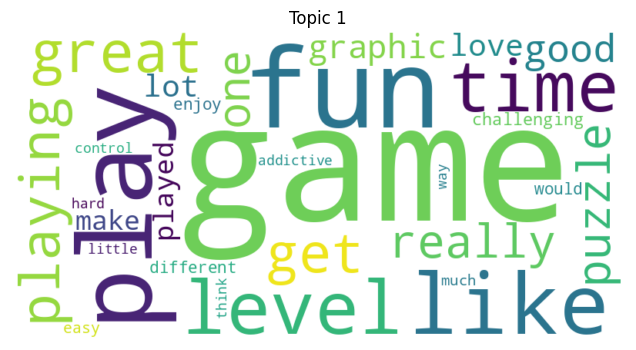

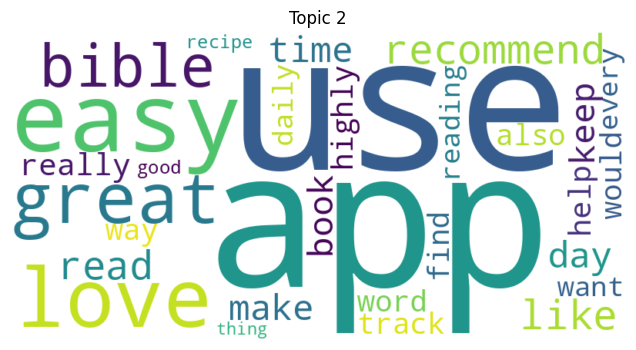

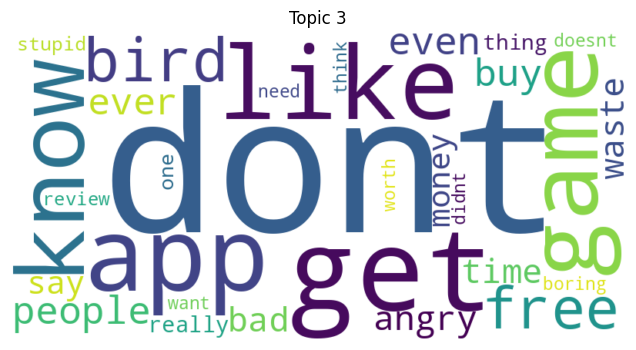

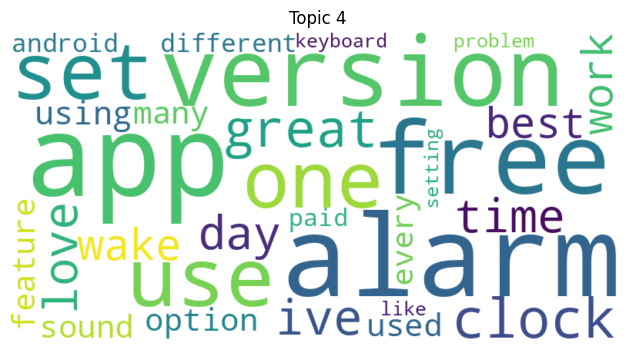

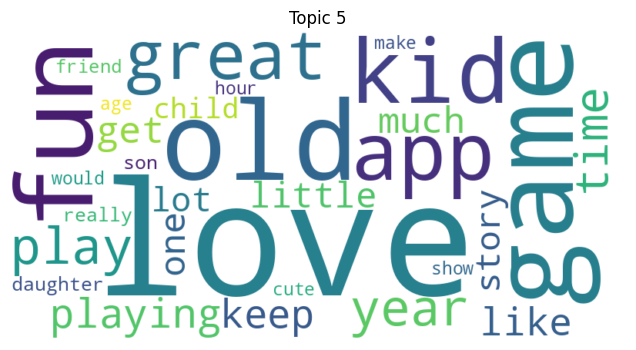

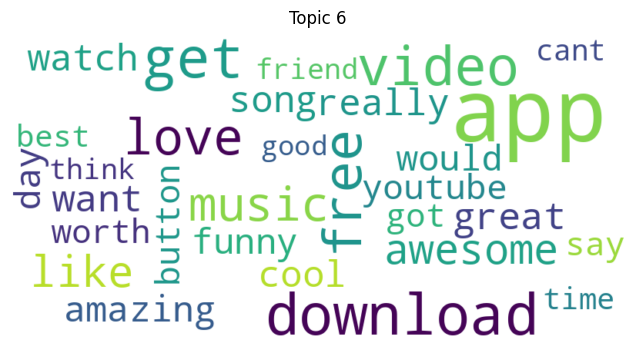

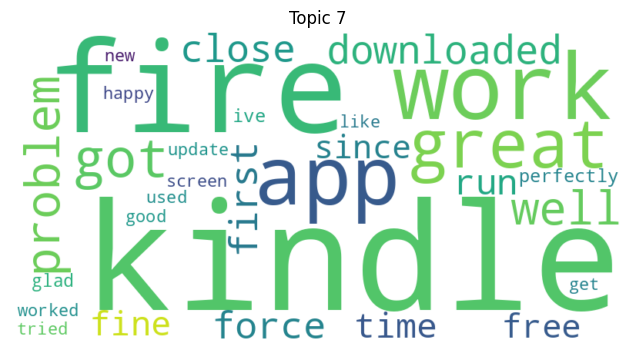

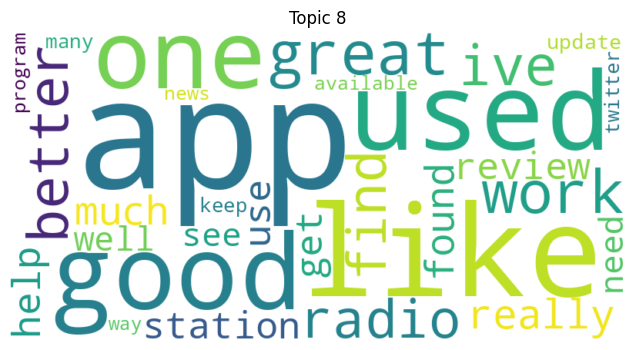

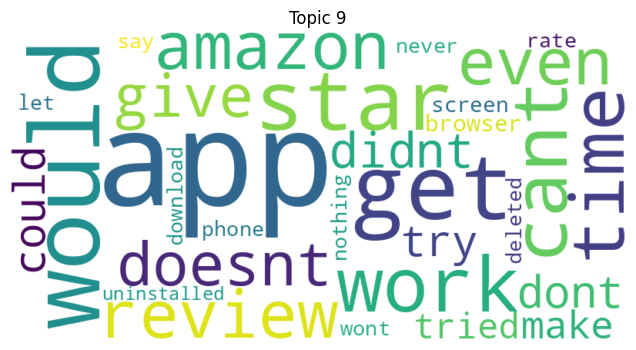

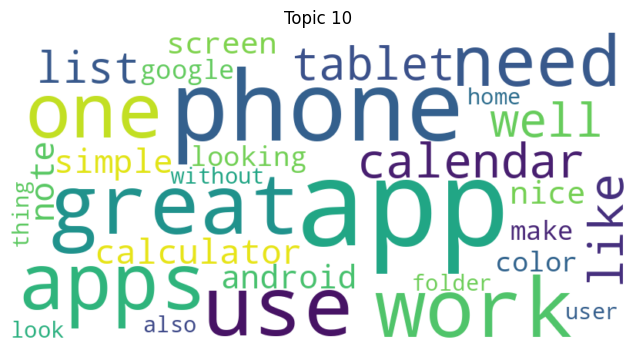

In [32]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordclouds(model, feature_names, n_topics=10, top_n=30):
    for topic_idx, topic in enumerate(model.components_[:n_topics]):
        topic_words = {feature_names[i]: topic[i] for i in topic.argsort()[:-top_n - 1:-1]}
        wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(topic_words)
        plt.figure(figsize=(10, 4))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Topic {topic_idx + 1}")
        plt.show()

# Plot for LDA (using count_vectorizer)
plot_wordclouds(lda_model, count_vectorizer.get_feature_names_out())


[Back to the top](#table-of-contents)
___


<a id="edge-cases"></a>  
# 🧪 Edge Cases & Troubleshooting



#### ⚠️ Short Texts & Low Topic Separation  
<a id="short-texts"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🪫 Why LDA Struggles with Short Texts

LDA assumes that:
- Each **document** is a mix of topics
- Each topic has a clear word distribution

But in **short texts** (tweets, reviews, comments), there are too few words to infer any real “mix.”  
You end up with:
- 🔕 Repetitive topics
- 🧩 Overlapping top words
- 🎭 Vague or incoherent groupings

📎 Fixes:
- Group documents (e.g., by user/product/time window)
- Use NMF with TF-IDF (better for sparse short texts)
- Try `BERTopic`, `Top2Vec`, or em

#### 🧪 Poor Topic Coherence  
<a id="poor-coherence"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🤷 Why Topics Sometimes Suck

Even with solid cleaning, topic models can output garbage:

- 💩 Topics with junk words (`one`, `thing`, `like`, `would`)
- 🌀 Same top words across multiple topics
- 🫠 Incoherent or ambiguous themes

This usually happens because of:
- ⚖️ Poor `n_topics` choice
- 🦠 Noisy or generic documents
- 🧪 Weak signal in the data

🧯 What You Can Try:
- Tune `n_components` (more or fewer topics)
- Filter frequent/uninformative words manually
- Drop or cluster low-frequency documents
- Use **coherence** as tuning guide, not just perplexity

Sometimes, topics are just bad because the data is bad. Don’t over-model noise.

</details>


[Back to the top](#table-of-contents)
___
